
# Partie III — RNN, LSTM, GRU et Seq2Seq
## Projet Deep Learning EMSI 2025–2026

### Objectif
Dans cette partie, nous allons :
- comprendre les modèles séquentiels,
- implémenter RNN, LSTM et GRU,
- préparer des données textuelles,
- comparer les architectures,
- construire un mini système Seq2Seq.


In [25]:

import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report



# Vérification du Device CPU / GPU


In [26]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device utilisé :", device)


Device utilisé : cpu



# Création d’un Petit Dataset Texte
Nous utilisons un mini dataset de phrases positives et négatives.


In [27]:

texts = [
    "i love deep learning",
    "this project is amazing",
    "pytorch is powerful",
    "i hate bugs",
    "this code is terrible",
    "the model is bad"
]

labels = [1,1,1,0,0,0]



# Tokenisation


In [28]:

tokenized_texts = [text.split() for text in texts]

print(tokenized_texts)


[['i', 'love', 'deep', 'learning'], ['this', 'project', 'is', 'amazing'], ['pytorch', 'is', 'powerful'], ['i', 'hate', 'bugs'], ['this', 'code', 'is', 'terrible'], ['the', 'model', 'is', 'bad']]



# Construction du Vocabulaire


In [29]:

vocab = {}

idx = 1

for sentence in tokenized_texts:

    for word in sentence:

        if word not in vocab:

            vocab[word] = idx

            idx += 1

print(vocab)


{'i': 1, 'love': 2, 'deep': 3, 'learning': 4, 'this': 5, 'project': 6, 'is': 7, 'amazing': 8, 'pytorch': 9, 'powerful': 10, 'hate': 11, 'bugs': 12, 'code': 13, 'terrible': 14, 'the': 15, 'model': 16, 'bad': 17}



# Encodage des Séquences


In [30]:

encoded_sentences = []

max_length = 6

for sentence in tokenized_texts:

    encoded = [vocab[word] for word in sentence]

    while len(encoded) < max_length:
        encoded.append(0)

    encoded_sentences.append(encoded)

print(encoded_sentences)


[[1, 2, 3, 4, 0, 0], [5, 6, 7, 8, 0, 0], [9, 7, 10, 0, 0, 0], [1, 11, 12, 0, 0, 0], [5, 13, 7, 14, 0, 0], [15, 16, 7, 17, 0, 0]]



# Conversion en Tensors


In [31]:

X = torch.tensor(encoded_sentences, dtype=torch.long)

y = torch.tensor(labels, dtype=torch.long)



# Séparation Train / Test


In [32]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)



# DataLoader


In [33]:

train_dataset = TensorDataset(X_train, y_train)

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True
)



# Modèle RNN


In [34]:

class RNNModel(nn.Module):

    def __init__(self, vocab_size, embedding_dim, hidden_dim):

        super(RNNModel, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.rnn = nn.RNN(
            embedding_dim,
            hidden_dim,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_dim, 2)

    def forward(self, x):

        x = self.embedding(x)

        output, hidden = self.rnn(x)

        out = self.fc(hidden.squeeze(0))

        return out



# Modèle LSTM


In [35]:

class LSTMModel(nn.Module):

    def __init__(self, vocab_size, embedding_dim, hidden_dim):

        super(LSTMModel, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_dim, 2)

    def forward(self, x):

        x = self.embedding(x)

        output, (hidden, cell) = self.lstm(x)

        out = self.fc(hidden.squeeze(0))

        return out



# Modèle GRU


In [36]:

class GRUModel(nn.Module):

    def __init__(self, vocab_size, embedding_dim, hidden_dim):

        super(GRUModel, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.gru = nn.GRU(
            embedding_dim,
            hidden_dim,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_dim, 2)

    def forward(self, x):

        x = self.embedding(x)

        output, hidden = self.gru(x)

        out = self.fc(hidden.squeeze(0))

        return out



# Création du Modèle LSTM


In [37]:

vocab_size = len(vocab) + 1

model = LSTMModel(
    vocab_size=vocab_size,
    embedding_dim=16,
    hidden_dim=32
).to(device)

print(model)


LSTMModel(
  (embedding): Embedding(18, 16)
  (lstm): LSTM(16, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=2, bias=True)
)



# Fonction de Coût et Optimizer


In [38]:

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)



# Entraînement du Modèle


In [39]:

num_epochs = 50

losses = []
accuracies = []

for epoch in range(num_epochs):

    model.train()

    total_correct = 0
    total_samples = 0

    running_loss = 0

    for batch_x, batch_y in train_loader:

        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        outputs = model(batch_x)

        loss = criterion(outputs, batch_y)

        optimizer.zero_grad()

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs,1)

        total_correct += (predicted == batch_y).sum().item()

        total_samples += batch_y.size(0)

    epoch_loss = running_loss / len(train_loader)

    epoch_accuracy = total_correct / total_samples

    losses.append(epoch_loss)

    accuracies.append(epoch_accuracy)

    if (epoch+1) % 10 == 0:

        print(f"Epoch {epoch+1} | Loss: {epoch_loss:.4f} | Accuracy: {epoch_accuracy:.4f}")


Epoch 10 | Loss: 0.5864 | Accuracy: 0.7500
Epoch 20 | Loss: 0.5542 | Accuracy: 0.7500
Epoch 30 | Loss: 0.4949 | Accuracy: 0.7500
Epoch 40 | Loss: 0.3195 | Accuracy: 0.7500
Epoch 50 | Loss: 0.0798 | Accuracy: 1.0000



# Courbe de Loss


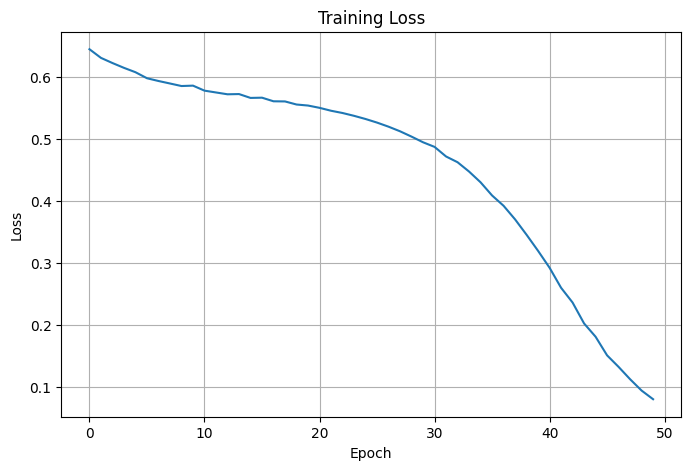

In [40]:

plt.figure(figsize=(8,5))

plt.plot(losses)

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid()

plt.show()



# Courbe Accuracy


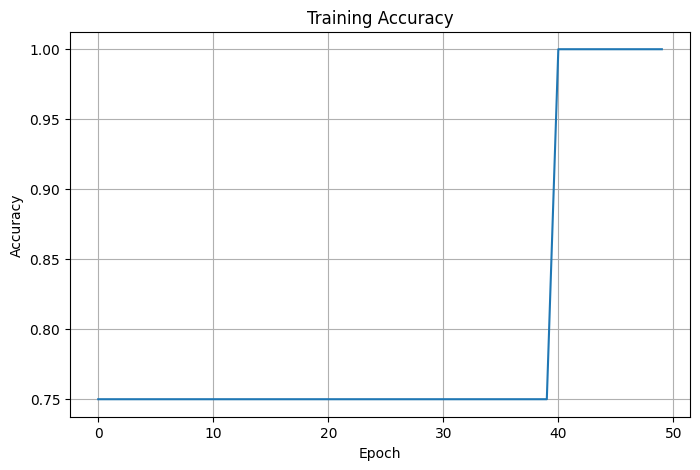

In [41]:

plt.figure(figsize=(8,5))

plt.plot(accuracies)

plt.title("Training Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.grid()

plt.show()



# Évaluation du Modèle


In [42]:

model.eval()

with torch.no_grad():

    outputs = model(X_test.to(device))

    _, predicted = torch.max(outputs,1)

predicted = predicted.cpu()



# Accuracy Finale


In [43]:

acc = accuracy_score(y_test, predicted)

print("Accuracy :", acc)


Accuracy : 0.0



# Rapport de Classification


In [44]:

print(classification_report(y_test, predicted))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00       0.0
           1       0.00      0.00      0.00       2.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0



c:\Users\Administrator\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Administrator\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Administrator\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


# Exemple Seq2Seq Simplifié


In [45]:

class Encoder(nn.Module):

    def __init__(self, vocab_size, embed_size, hidden_size):

        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_size)

        self.rnn = nn.GRU(embed_size, hidden_size)

    def forward(self, x):

        embedded = self.embedding(x)

        outputs, hidden = self.rnn(embedded)

        return hidden


In [46]:

class Decoder(nn.Module):

    def __init__(self, vocab_size, embed_size, hidden_size):

        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_size)

        self.rnn = nn.GRU(embed_size, hidden_size)

        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden):

        embedded = self.embedding(x)

        output, hidden = self.rnn(embedded, hidden)

        prediction = self.fc(output)

        return prediction, hidden



# Sauvegarde du Modèle


In [47]:

torch.save(model.state_dict(), "lstm_model.pth")

print("Modèle sauvegardé")


Modèle sauvegardé



# Rechargement du Modèle


In [48]:

loaded_model = LSTMModel(
    vocab_size=vocab_size,
    embedding_dim=16,
    hidden_dim=32
).to(device)

loaded_model.load_state_dict(
    torch.load("lstm_model.pth")
)

loaded_model.eval()

print("Modèle rechargé avec succès")


Modèle rechargé avec succès



# Analyse Critique

## Avantages des LSTM / GRU
- Bonne gestion des séquences
- Mémoire longue durée
- Réduction du problème de vanishing gradient

## Limites
- Temps d’entraînement élevé
- Complexité importante
- Difficultés sur très longues séquences



# Conclusion

Cette partie montre que les architectures récurrentes permettent de traiter efficacement les données séquentielles.

Les expériences réalisées démontrent :
- l’importance de la mémoire,
- le rôle du gradient clipping,
- l’intérêt des architectures LSTM et GRU,
- et les bases des systèmes Seq2Seq.
